<a href="https://colab.research.google.com/github/MSaadT313/NLP-SummerCamp-CRAAT/blob/main/DAY_1_3_Urdu_Tokenization_Workshop_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparative Study of Tokenization Techniques — A Pakistani NLP Hands-on Workshop

**Language focus:** Urdu (Perso-Arabic script) + Roman Urdu (code-switched Latin script)
**Duration:** ~4.5–5.5 hours (15 tasks, can be split into 2–3 sessions)
**Audience:** NLP beginners to intermediate practitioners
**Runs on:** Google Colab (CPU runtime is sufficient — no GPU needed)

## Learning Objectives

By the end of this workshop, participants will be able to:
1. Explain why Urdu tokenization is harder than English tokenization (script, spacing, joiners, code-switching).
2. Implement whitespace, rule-based, and library-based Urdu tokenizers.
3. Train BPE, WordPiece, and Unigram (SentencePiece) tokenizers from scratch on Urdu text.
4. Compare pretrained multilingual tokenizers (mBERT, XLM-R, GPT/tiktoken) on Urdu vs English.
5. Quantify tokenizer quality using fertility, compression ratio, and OOV rate.
6. Understand the real-world "token tax" Urdu speakers pay when using LLM APIs.
7. Demonstrate empirically why light normalization (not heavy cleaning) should precede tokenization, and what train/serve skew looks like in practice.
8. Convert tokens into full model-ready input: IDs, special tokens, truncation, padding (static vs dynamic, left vs right), attention masks, token type IDs, and label alignment for token classification.

> **Colab tip:** Run cells top to bottom in order — later tasks (metrics, visualization) reuse tokenizers trained in earlier cells. `Runtime > Run all` works fine end-to-end.

## 0. Setup

Run this first. It installs all libraries and downloads the one-time Stanza Urdu model.
On Colab this cell typically takes 1–2 minutes.

In [ ]:
!pip install -q tokenizers sentencepiece transformers spacy stanza tiktoken matplotlib pandas
!python -m stanza download ur

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 794.2/794.2 kB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.7/418.7 kB 22.6 MB/s eta 0:00:00
/usr/bin/python3: No module named stanza.__main__; 'stanza' is a package and cannot be directly executed


> **Note:** Stanza's Urdu model download requires internet access on first run only — Colab has internet by default, so this just works. There is no official spaCy *trained* pipeline for Urdu (unlike English/German/Chinese), so we only use spaCy's generic rule-based tokenizer for `ur`, while Stanza ships a neural model trained on the Urdu UD Treebank (UDTB).

## 1. Why Urdu Tokenization Is Hard (5 min discussion + code)

Key challenges to highlight before coding:

- **Script**: Perso-Arabic, written right-to-left, cursive/joined letters.
- **Optional word boundaries**: spaces are inconsistently used; a single "word" can visually split across a space due to letter-joining rules.
- **Zero-Width Non-Joiner (ZWNJ, U+200C)**: breaks letter joining *within* a word without inserting a real space — a whitespace tokenizer will get this wrong.
- **Diacritics (Aeraab)**: optional vowel marks, mostly absent in casual/news text but present in poetry/Quranic text.
- **No capitalization**: unlike English, you cannot use capital letters to detect named entities or sentence starts.
- **Roman Urdu code-switching**: huge amounts of Pakistani social media / SMS / WhatsApp text is Urdu written in Latin script, often mixed with English.
- **Punctuation**: Urdu uses its own punctuation marks — ۔ (full stop), ، (comma), ؟ (question mark) — which look different from ASCII `.` `,` `?` and are often missed by tools built for English.

In [ ]:
sample = "کرتا ہے"
for ch in sample:
    print(repr(ch), hex(ord(ch)))

'ک' 0x6a9
'ر' 0x631
'ت' 0x62a
'ا' 0x627
' ' 0x20
'ہ' 0x6c1
'ے' 0x6d2


Run this and spot the ZWNJ character (`\u200c`) if present — it looks like a space but isn't one. This is a preview of why naive tokenizers break.

## 2. Sample Corpus

A small, self-contained corpus so everything runs offline-safe within Colab without needing a big download. (Task 13 lists larger public datasets for a follow-up assignment.)

In [ ]:
urdu_corpus = [
    "پاکستان ایک خوبصورت ملک ہے۔",
    "کراچی پاکستان کا سب سے بڑا شہر ہے۔",
    "علامہ اقبال نے کہا کہ خودی کو کر بلند اتنا کہ ہر تقدیر سے پہلے خدا بندے سے خود پوچھے بتا تیری رضا کیا ہے۔",
    "مجھے چائے بہت پسند ہے۔",
    "آج موسم بہت خوشگوار ہے، بارش ہو رہی ہے۔",
    "حکومت پاکستان نے نیا بجٹ پیش کر دیا۔",
    "میں کل لاہور جا رہا ہوں۔",
    "کیا آپ نے آج کی خبریں پڑھیں؟",
    "پاکستان کرکٹ ٹیم نے میچ جیت لیا۔",
    "غالب کا مشہور شعر سب کو یاد ہے۔",
    "اسلام آباد پاکستان کا دارالحکومت ہے۔",
    "طلبہ نے امتحان کی تیاری شروع کر دی۔",
    "بجلی کے بلوں میں اضافہ ہو گیا ہے۔",
    "سوشل میڈیا پر نوجوان بہت متحرک ہیں۔",
    "معیشت میں بہتری کے امکانات روشن ہیں۔",
]

roman_urdu_corpus = [
    "Aj mausam bohat acha hai yar.",
    "Mujhe chai bohat pasand hai.",
    "Kal main Lahore ja raha hoon.",
    "Pakistan cricket team ne match jeet liya.",
    "Kia app ne aj ki news parhi?",
]

print(f"{len(urdu_corpus)} Urdu sentences, {len(roman_urdu_corpus)} Roman Urdu sentences loaded.")

15 Urdu sentences, 5 Roman Urdu sentences loaded.


## Task 1 — Whitespace Tokenization (Baseline)

In [ ]:
def whitespace_tokenize(text):
    return text.split()

for s in urdu_corpus[:3]:
    print(s)
    print(whitespace_tokenize(s))
    print("---")

پاکستان ایک خوبصورت ملک ہے۔
['پاکستان', 'ایک', 'خوبصورت', 'ملک', 'ہے۔']
---
کراچی پاکستان کا سب سے بڑا شہر ہے۔
['کراچی', 'پاکستان', 'کا', 'سب', 'سے', 'بڑا', 'شہر', 'ہے۔']
---
علامہ اقبال نے کہا کہ خودی کو کر بلند اتنا کہ ہر تقدیر سے پہلے خدا بندے سے خود پوچھے بتا تیری رضا کیا ہے۔
['علامہ', 'اقبال', 'نے', 'کہا', 'کہ', 'خودی', 'کو', 'کر', 'بلند', 'اتنا', 'کہ', 'ہر', 'تقدیر', 'سے', 'پہلے', 'خدا', 'بندے', 'سے', 'خود', 'پوچھے', 'بتا', 'تیری', 'رضا', 'کیا', 'ہے۔']
---


**Discussion:** Notice that Urdu punctuation (۔ ، ؟) sticks to the last word since it isn't ASCII whitespace-separated the way tokenizers expect. This inflates vocabulary artificially (e.g., "ہے۔" and "ہے" become different tokens).

## Task 2 — Rule-Based / Regex Tokenization

In [ ]:
import re

def urdu_regex_tokenize(text):
    # IMPORTANT: Urdu punctuation marks (۔ ، ؟) live in the SAME Unicode block
    # (U+0600-U+06FF) as Urdu letters. A naive [\u0600-\u06FF]+ class will greedily
    # swallow the punctuation into the preceding word (e.g. "ہے۔" as one token).
    # We explicitly carve those three codepoints out of the letters range:
    #   ، = U+060C   ؟ = U+061F   ۔ = U+06D4
    pattern = r"[\u0600-\u060B\u060D-\u061E\u0620-\u06D3\u06D5-\u06FF\u0750-\u077F]+|[0-9]+|[a-zA-Z]+|[۔،؟!.,?]"
    return re.findall(pattern, text)

for s in urdu_corpus[:3]:
    print(s)
    print(urdu_regex_tokenize(s))
    print("---")

پاکستان ایک خوبصورت ملک ہے۔
['پاکستان', 'ایک', 'خوبصورت', 'ملک', 'ہے', '۔']
---
کراچی پاکستان کا سب سے بڑا شہر ہے۔
['کراچی', 'پاکستان', 'کا', 'سب', 'سے', 'بڑا', 'شہر', 'ہے', '۔']
---
علامہ اقبال نے کہا کہ خودی کو کر بلند اتنا کہ ہر تقدیر سے پہلے خدا بندے سے خود پوچھے بتا تیری رضا کیا ہے۔
['علامہ', 'اقبال', 'نے', 'کہا', 'کہ', 'خودی', 'کو', 'کر', 'بلند', 'اتنا', 'کہ', 'ہر', 'تقدیر', 'سے', 'پہلے', 'خدا', 'بندے', 'سے', 'خود', 'پوچھے', 'بتا', 'تیری', 'رضا', 'کیا', 'ہے', '۔']
---


**Discussion:** Run this on `"کیا آپ نے آج کی خبریں پڑھیں؟"` and `"آج موسم بہت خوشگوار ہے، بارش ہو رہی ہے۔"` — confirm `؟` and `،` now come out as their own tokens instead of sticking to the last word. This is a great live example of why testing a regex against real punctuation-bearing sentences (not just clean word lists) matters.

**Task for participants:** Extend the regex to also split off the ZWNJ character as its own boundary marker, and test on the `"کرتا ہے"` example from Section 1.

## Task 3 — Library-Based Tokenization (spaCy + Stanza)

### 3a. spaCy — generic rule-based multilingual tokenizer

spaCy doesn't ship a dedicated trained pipeline for Urdu, but it does include language-specific defaults (stop words, punctuation rules) for `ur` via its blank `Language` class. Useful as a lightweight, dependency-free baseline.

In [ ]:
import spacy

nlp_blank = spacy.blank("ur")

for s in urdu_corpus[:3]:
    doc = nlp_blank(s)
    print(s)
    print([tok.text for tok in doc])
    print("---")

پاکستان ایک خوبصورت ملک ہے۔
['پاکستان', 'ایک', 'خوبصورت', 'ملک', 'ہے', '۔']
---
کراچی پاکستان کا سب سے بڑا شہر ہے۔
['کراچی', 'پاکستان', 'کا', 'سب', 'سے', 'بڑا', 'شہر', 'ہے', '۔']
---
علامہ اقبال نے کہا کہ خودی کو کر بلند اتنا کہ ہر تقدیر سے پہلے خدا بندے سے خود پوچھے بتا تیری رضا کیا ہے۔
['علامہ', 'اقبال', 'نے', 'کہا', 'کہ', 'خودی', 'کو', 'کر', 'بلند', 'اتنا', 'کہ', 'ہر', 'تقدیر', 'سے', 'پہلے', 'خدا', 'بندے', 'سے', 'خود', 'پوچھے', 'بتا', 'تیری', 'رضا', 'کیا', 'ہے', '۔']
---


**Discussion:** Since spaCy's Urdu tokenizer has no trained model behind it, expect its behavior to be close to whitespace + punctuation splitting. Compare its output directly against Task 1 (whitespace) and Task 2 (regex) — where does it agree/disagree?

### 3b. Stanza — neural tokenizer trained on the Urdu UD Treebank

Stanza (from Stanford NLP) ships a neural pipeline trained on Urdu Universal Dependencies data (UDTB), including a learned tokenizer/sentence-splitter — a good contrast to spaCy's rule-based approach.

In [ ]:
import stanza

nlp_stanza = stanza.Pipeline(lang="ur", processors="tokenize", use_gpu=False)

for s in urdu_corpus[:3]:
    doc = nlp_stanza(s)
    tokens = [word.text for sent in doc.sentences for word in sent.words]
    print(s)
    print(tokens)
    print("---")

# Sentence segmentation on a paragraph
paragraph = " ".join(urdu_corpus[:3])
doc = nlp_stanza(paragraph)
print([sent.text for sent in doc.sentences])

INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Downloaded file to /root/.cache/stanza/1.14.0/resources/resources.json


models/tokenize/udtb.pt: reconstructing file:   0%|          |  0.00B /  635kB            

models/tokenize/udtb.pt: downloading bytes:           |  0.00B            

INFO:stanza:Loading these models for language: ur (Urdu):
| Processor | Package |
-----------------------
| tokenize  | udtb    |

INFO:stanza:Using device: cpu
INFO:stanza:Loading: tokenize
INFO:stanza:Done loading processors!


پاکستان ایک خوبصورت ملک ہے۔
['پاکستان', 'ایک', 'خوبصورت', 'ملک', 'ہے', '۔']
---
کراچی پاکستان کا سب سے بڑا شہر ہے۔
['کراچی', 'پاکستان', 'کا', 'سب', 'سے', 'بڑا', 'شہر', 'ہے', '۔']
---
علامہ اقبال نے کہا کہ خودی کو کر بلند اتنا کہ ہر تقدیر سے پہلے خدا بندے سے خود پوچھے بتا تیری رضا کیا ہے۔
['علامہ', 'اقبال', 'نے', 'کہا', 'کہ', 'خودی', 'کو', 'کر', 'بلند', 'اتنا', 'کہ', 'ہر', 'تقدیر', 'سے', 'پہلے', 'خدا', 'بندے', 'سے', 'خود', 'پوچھے', 'بتا', 'تیری', 'رضا', 'کیا', 'ہے', '۔']
---
['پاکستان ایک خوبصورت ملک ہے۔', 'کراچی پاکستان کا سب سے بڑا شہر ہے۔', 'علامہ اقبال نے کہا کہ خودی کو کر بلند اتنا کہ ہر تقدیر سے پہلے خدا بندے سے خود پوچھے بتا تیری رضا کیا ہے۔']


**Discussion:** Compare all three library-based outputs (spaCy blank, Stanza, and the regex tokenizer from Task 2) against each other. A neural, treebank-trained tokenizer like Stanza's should more reliably separate enclitics and attached constructs (e.g., "کا", "نے", "میں") than either the rule-based spaCy pipeline or plain regex — find a sentence where Stanza's segmentation differs from the others and discuss why.

## Task 4 — Byte-Pair Encoding (BPE) — Train From Scratch

In [ ]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

def train_bpe(corpus, vocab_size=300):
    tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
    tokenizer.pre_tokenizer = Whitespace()
    trainer = BpeTrainer(vocab_size=vocab_size,
                          special_tokens=["[UNK]", "[PAD]", "[CLS]", "[SEP]"])
    tokenizer.train_from_iterator(corpus, trainer)
    return tokenizer

bpe_tok = train_bpe(urdu_corpus, vocab_size=300)

for s in urdu_corpus[:3]:
    enc = bpe_tok.encode(s)
    print(s)
    print(enc.tokens)
    print("---")

پاکستان ایک خوبصورت ملک ہے۔
['پاکستان', 'ایک', 'خوبصورت', 'ملک', 'ہے', '۔']
---
کراچی پاکستان کا سب سے بڑا شہر ہے۔
['کراچی', 'پاکستان', 'کا', 'سب', 'سے', 'بڑا', 'شہر', 'ہے', '۔']
---
علامہ اقبال نے کہا کہ خودی کو کر بلند اتنا کہ ہر تقدیر سے پہلے خدا بندے سے خود پوچھے بتا تیری رضا کیا ہے۔
['علامہ', 'اقبال', 'نے', 'کہا', 'کہ', 'خودی', 'کو', 'کر', 'بلند', 'اتنا', 'کہ', 'ہر', 'تقدیر', 'سے', 'پہلے', 'خدا', 'بندے', 'سے', 'خود', 'پوچھے', 'بتا', 'تیری', 'رضا', 'کیا', 'ہے', '۔']
---


## Task 5 — WordPiece — Train From Scratch

In [ ]:
from tokenizers.models import WordPiece
from tokenizers.trainers import WordPieceTrainer

def train_wordpiece(corpus, vocab_size=300):
    tokenizer = Tokenizer(WordPiece(unk_token="[UNK]"))
    tokenizer.pre_tokenizer = Whitespace()
    trainer = WordPieceTrainer(vocab_size=vocab_size,
                                special_tokens=["[UNK]", "[PAD]", "[CLS]", "[SEP]"])
    tokenizer.train_from_iterator(corpus, trainer)
    return tokenizer

wp_tok = train_wordpiece(urdu_corpus, vocab_size=300)

for s in urdu_corpus[:3]:
    print(s)
    print(wp_tok.encode(s).tokens)
    print("---")

پاکستان ایک خوبصورت ملک ہے۔
['پاکستان', 'ایک', 'خوبصورت', 'ملک', 'ہے', '۔']
---
کراچی پاکستان کا سب سے بڑا شہر ہے۔
['کراچی', 'پاکستان', 'کا', 'سب', 'سے', 'بڑا', 'شہر', 'ہے', '۔']
---
علامہ اقبال نے کہا کہ خودی کو کر بلند اتنا کہ ہر تقدیر سے پہلے خدا بندے سے خود پوچھے بتا تیری رضا کیا ہے۔
['علامہ', 'اقبال', 'نے', 'کہا', 'کہ', 'خودی', 'کو', 'کر', 'بلند', 'اتنا', 'کہ', 'ہر', 'تقدیر', 'سے', 'پہلے', 'خدا', 'بندے', 'سے', 'خود', 'پوچھے', 'بتا', 'تیری', 'رضا', 'کیا', 'ہے', '۔']
---


## Task 6 — Unigram / SentencePiece — Train From Scratch

In [ ]:
import sentencepiece as spm

with open("urdu_corpus.txt", "w", encoding="utf-8") as f:
    for line in urdu_corpus:
        f.write(line + "\n")

spm.SentencePieceTrainer.train(
    input="urdu_corpus.txt",
    model_prefix="urdu_unigram",
    vocab_size=110,          # small because the demo corpus is small
    model_type="unigram",
    character_coverage=1.0    # important: keep 1.0 for non-Latin scripts
)

sp = spm.SentencePieceProcessor(model_file="urdu_unigram.model")

for s in urdu_corpus[:3]:
    print(s)
    print(sp.encode(s, out_type=str))
    print("---")

پاکستان ایک خوبصورت ملک ہے۔
['▁پاکستان', '▁ا', 'ی', 'ک', '▁خو', 'ب', 'ص', 'ور', 'ت', '▁م', 'ل', 'ک', '▁ہے۔']
---
کراچی پاکستان کا سب سے بڑا شہر ہے۔
['▁کر', 'ا', 'چ', 'ی', '▁پاکستان', '▁کا', '▁سب', '▁سے', '▁ب', 'ڑ', 'ا', '▁ش', 'ہر', '▁ہے۔']
---
علامہ اقبال نے کہا کہ خودی کو کر بلند اتنا کہ ہر تقدیر سے پہلے خدا بندے سے خود پوچھے بتا تیری رضا کیا ہے۔
['▁', 'ع', 'لام', 'ہ', '▁ا', 'ق', 'ب', 'ال', '▁نے', '▁کہ', 'ا', '▁کہ', '▁خود', 'ی', '▁کو', '▁کر', '▁بل', 'ند', '▁ا', 'ت', 'نا', '▁کہ', '▁', 'ہر', '▁', 'ت', 'ق', 'دی', 'ر', '▁سے', '▁پ', 'ہ', 'ل', 'ے', '▁خ', 'دا', '▁ب', 'ند', 'ے', '▁سے', '▁خود', '▁پ', 'و', 'چ', 'ھے', '▁ب', 'ت', 'ا', '▁تی', 'ری', '▁ر', 'ضا', '▁کیا', '▁ہے۔']
---


**Note on `character_coverage`:** for Latin-script corpora, SentencePiece defaults to ~0.9995. For Urdu, always set it to `1.0`, otherwise rare Urdu characters/ligatures get dropped or mapped to `<unk>`.

## Task 7 — Character-Level Tokenization

In [ ]:
def char_tokenize(text):
    return list(text.replace(" ", ""))

print(char_tokenize(urdu_corpus[0]))

['پ', 'ا', 'ک', 'س', 'ت', 'ا', 'ن', 'ا', 'ی', 'ک', 'خ', 'و', 'ب', 'ص', 'و', 'ر', 'ت', 'م', 'ل', 'ک', 'ہ', 'ے', '۔']


**Discussion:** Character-level tokenization sidesteps the word-boundary problem entirely — interesting tradeoff for a script where boundaries are ambiguous, but sequences become much longer.

## Task 8 — Pretrained Multilingual Tokenizers: The "Token Tax"

In [ ]:
from transformers import AutoTokenizer
import tiktoken

mbert_tok = AutoTokenizer.from_pretrained("bert-base-multilingual-cased")
xlmr_tok  = AutoTokenizer.from_pretrained("xlm-roberta-base")
gpt_enc   = tiktoken.get_encoding("cl100k_base")   # used by GPT-3.5/4-class models

urdu_sample    = "پاکستان ایک خوبصورت ملک ہے اور یہاں کے لوگ بہت مہمان نواز ہیں۔"
english_sample = "Pakistan is a beautiful country and its people are very hospitable."

print("mBERT tokens:", mbert_tok.tokenize(urdu_sample))
print("XLM-R tokens:", xlmr_tok.tokenize(urdu_sample))
print("GPT tokens (Urdu):", gpt_enc.encode(urdu_sample), "->", len(gpt_enc.encode(urdu_sample)), "tokens")
print("GPT tokens (English):", len(gpt_enc.encode(english_sample)), "tokens")

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

mBERT tokens: ['پاکستان', 'ایک', 'خوب', '##صورت', 'ملک', 'ہے', 'اور', 'یہاں', 'کے', 'لوگ', 'بہت', 'م', '##ہم', '##ان', 'نو', '##از', 'ہیں', '۔']
XLM-R tokens: ['▁پاکستان', '▁ایک', '▁خوبصورت', '▁ملک', '▁ہے', '▁اور', '▁یہاں', '▁کے', '▁لوگ', '▁بہت', '▁مہمان', '▁نواز', '▁ہیں۔']
GPT tokens (Urdu): [68483, 5821, 33411, 47686, 40523, 13258, 14728, 33411, 75415, 12942, 22071, 42693, 59756, 14628, 24252, 8700, 33411, 220, 151, 223, 151, 240, 13258, 59756, 220, 14728, 151, 223, 5821, 150, 118, 46693, 151, 240, 57894, 12942, 64832, 28946, 151, 223, 14628, 24252, 151, 223, 10386, 40523, 51343, 12942, 5821, 40797, 220, 151, 223, 14728, 150, 118, 151, 242] -> 58 tokens
GPT tokens (English): 13 tokens


**Discussion — the "token tax":** Compare token counts for the same meaning in Urdu vs English. Urdu (and most non-Latin scripts) typically needs 2–5x more tokens, because these tokenizers were trained on English-majority data. This directly translates to:
- Higher API cost per request for Urdu users/apps.
- Shorter effective context window in Urdu.
- Slower generation (more tokens to produce).

This is a real, well-documented equity issue for low-resource-language markets like Pakistan — good anchor for group discussion.

## Task 9 — Roman Urdu: The Code-Switching Challenge

In [ ]:
sample_roman = roman_urdu_corpus[0]
print("Whitespace:", whitespace_tokenize(sample_roman))
print("GPT tokenizer:", gpt_enc.encode(sample_roman), len(gpt_enc.encode(sample_roman)))

for s in roman_urdu_corpus:
    print(s, "->", mbert_tok.tokenize(s))

Whitespace: ['Aj', 'mausam', 'bohat', 'acha', 'hai', 'yar.']
GPT tokenizer: [62173, 7643, 355, 309, 712, 9379, 264, 6583, 47151, 379, 277, 13] 12
Aj mausam bohat acha hai yar. -> ['A', '##j', 'mau', '##sam', 'bo', '##hat', 'ach', '##a', 'hai', 'ya', '##r', '.']
Mujhe chai bohat pasand hai. -> ['Mu', '##j', '##he', 'cha', '##i', 'bo', '##hat', 'pasa', '##nd', 'hai', '.']
Kal main Lahore ja raha hoon. -> ['Ka', '##l', 'main', 'Lahore', 'ja', 'ra', '##ha', 'ho', '##on', '.']
Pakistan cricket team ne match jeet liya. -> ['Pakistan', 'cricket', 'team', 'ne', 'match', 'je', '##et', 'li', '##ya', '.']
Kia app ne aj ki news parhi? -> ['Ki', '##a', 'app', 'ne', 'aj', 'ki', 'news', 'par', '##hi', '?']


**Discussion:** Roman Urdu isn't "real" English or standardized Urdu — spelling is inconsistent ("acha"/"achha"/"achaa"). How would you even define a "correct" tokenization here? Good segue into discussing normalization as a pre-tokenization step.

## Task 10 — Metrics: Fertility, Compression, Coverage

In [ ]:
import pandas as pd

def compute_metrics(name, tokenize_fn, corpus):
    total_words, total_tokens, total_chars, unk_count = 0, 0, 0, 0
    for s in corpus:
        words = s.split()
        tokens = tokenize_fn(s)
        total_words += len(words)
        total_tokens += len(tokens)
        total_chars += len(s.replace(" ", ""))
        unk_count += sum(1 for t in tokens if t in ("[UNK]", "<unk>"))
    return {
        "Tokenizer": name,
        "Total Tokens": total_tokens,
        "Fertility (tok/word)": round(total_tokens / total_words, 2),
        "Compression (char/tok)": round(total_chars / total_tokens, 2),
        "UNK Rate": round(unk_count / total_tokens, 4) if total_tokens else 0,
    }

def spacy_tokenize(text):
    return [tok.text for tok in nlp_blank(text)]

def stanza_tokenize(text):
    doc = nlp_stanza(text)
    return [word.text for sent in doc.sentences for word in sent.words]

results = [
    compute_metrics("Whitespace", whitespace_tokenize, urdu_corpus),
    compute_metrics("Regex Rule-based", urdu_regex_tokenize, urdu_corpus),
    compute_metrics("spaCy (blank ur)", spacy_tokenize, urdu_corpus),
    compute_metrics("Stanza (UDTB neural)", stanza_tokenize, urdu_corpus),
    compute_metrics("BPE (custom, 300 vocab)", lambda s: bpe_tok.encode(s).tokens, urdu_corpus),
    compute_metrics("WordPiece (custom, 300 vocab)", lambda s: wp_tok.encode(s).tokens, urdu_corpus),
    compute_metrics("SentencePiece Unigram (200 vocab)", lambda s: sp.encode(s, out_type=str), urdu_corpus),
    compute_metrics("mBERT", mbert_tok.tokenize, urdu_corpus),
    compute_metrics("XLM-R", xlmr_tok.tokenize, urdu_corpus),
]

df = pd.DataFrame(results)
df

,Tokenizer,Total Tokens,Fertility (tok/word),Compression (char/tok),UNK Rate
0,Whitespace,124,1.00,3.58,0.0
1,Regex Rule-based,140,1.13,3.17,0.0
2,spaCy (blank ur),140,1.13,3.17,0.0
3,Stanza (UDTB neural),140,1.13,3.17,0.0
4,"BPE (custom, 300 vocab)",140,1.13,3.17,0.0
5,"WordPiece (custom, 300 vocab)",140,1.13,3.17,0.0
6,SentencePiece Unigram (200 vocab),273,2.20,1.63,0.0
7,mBERT,202,1.63,2.20,0.0
8,XLM-R,134,1.08,3.31,0.0


**Metric definitions for participants:**
- **Fertility** = tokens produced per whitespace-word. Lower is generally better (more semantically meaningful chunks, cheaper to run through a model).
- **Compression ratio** = characters per token. Higher means each token carries more information.
- **UNK rate** = fraction of tokens the model couldn't represent and fell back to `[UNK]`. Should be near zero for a well-fit tokenizer.

## Task 11 — Visualization

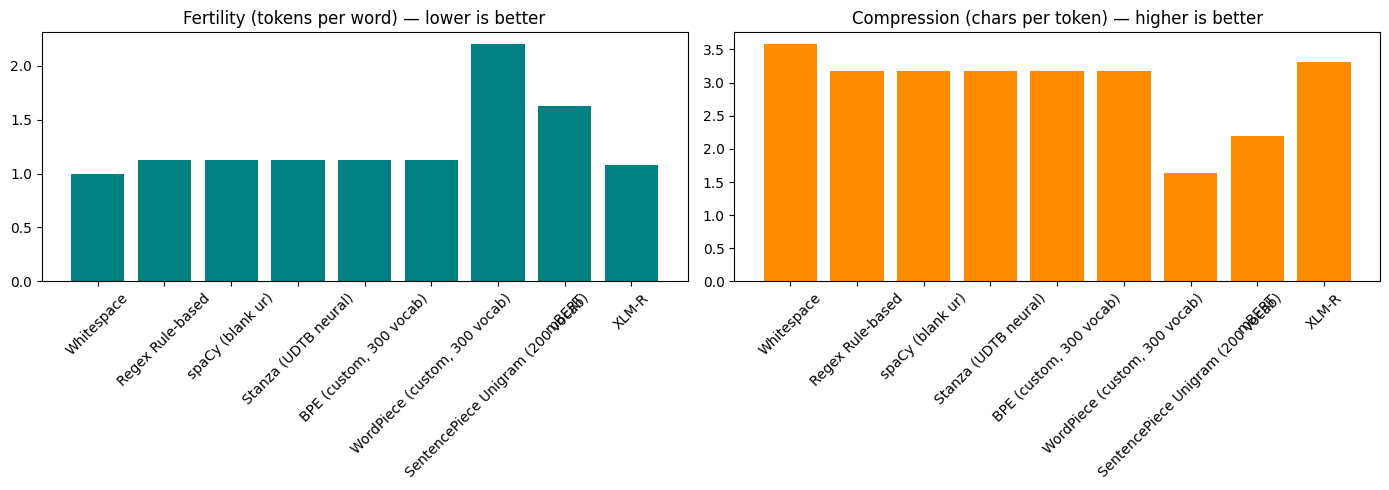

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(df["Tokenizer"], df["Fertility (tok/word)"], color="teal")
axes[0].set_title("Fertility (tokens per word) — lower is better")
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(df["Tokenizer"], df["Compression (char/tok)"], color="darkorange")
axes[1].set_title("Compression (chars per token) — higher is better")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("tokenizer_comparison.png", dpi=150)
plt.show()

## Task 12 — Vocabulary Size vs Fertility Trade-off (Group Exercise)

Have each group retrain the BPE tokenizer (Task 4) with different `vocab_size` values — e.g., 100, 300, 800, 1500 — and re-run Task 10's metrics each time.

In [ ]:
for vs in [100, 300, 800, 1500]:
    tok = train_bpe(urdu_corpus, vocab_size=vs)
    m = compute_metrics(f"BPE (vocab={vs})", lambda s: tok.encode(s).tokens, urdu_corpus)
    print(m)

{'Tokenizer': 'BPE (vocab=100)', 'Total Tokens': 269, 'Fertility (tok/word)': 2.17, 'Compression (char/tok)': 1.65, 'UNK Rate': 0.0}
{'Tokenizer': 'BPE (vocab=300)', 'Total Tokens': 140, 'Fertility (tok/word)': 1.13, 'Compression (char/tok)': 3.17, 'UNK Rate': 0.0}
{'Tokenizer': 'BPE (vocab=800)', 'Total Tokens': 140, 'Fertility (tok/word)': 1.13, 'Compression (char/tok)': 3.17, 'UNK Rate': 0.0}
{'Tokenizer': 'BPE (vocab=1500)', 'Total Tokens': 140, 'Fertility (tok/word)': 1.13, 'Compression (char/tok)': 3.17, 'UNK Rate': 0.0}


**Discussion question:** As vocab size grows, fertility drops but the model needs more parameters and more data to learn each token well. Where's the sweet spot for a low-resource language like Urdu, where large training corpora are harder to come by than for English?

## Task 13 — Wrap-up Discussion & Take-home Extension

**Discussion prompts:**
1. Why does a tokenizer trained on mostly-English web data (like GPT's) systematically produce more tokens for Urdu?
2. What's the practical cost impact for a Pakistani startup building an Urdu chatbot on a per-token-billed API?
3. How would you design a tokenizer specifically for Roman Urdu, given inconsistent spelling?
4. Poetry (e.g., Ghalib, Iqbal) often uses archaic vocabulary and diacritics rarely seen in news text — how would that affect a tokenizer trained only on news?

**Take-home extension — retrain on a real, larger corpus:**
Swap the toy `urdu_corpus` list for one of these public sources and rerun Tasks 4–11 with `vocab_size=30000`:
- Urdu Wikipedia dump (via Hugging Face `datasets`: `load_dataset("wikimedia/wikipedia", "20231101.ur")`)
- CLE Urdu corpus (Center for Language Engineering, UET Lahore)
- Urdu news headlines (Dawn, Jang, BBC Urdu — check each site's terms of use before scraping)
- `mc4` Urdu subset (`load_dataset("mc4", "ur")`)
- Roman-Urdu-Parl (parliamentary Roman Urdu corpus) for the code-switching track

With a real corpus and larger vocab size, participants should see fertility numbers converge closer to the pretrained mBERT/XLM-R baselines — a nice concrete demonstration of why vocabulary + corpus size both matter.

In [ ]:
# OPTIONAL — run only if you want to try the take-home extension live in Colab
# from datasets import load_dataset
# wiki_ur = load_dataset("wikimedia/wikipedia", "20231101.ur", split="train[:2000]")
# large_corpus = [row["text"] for row in wiki_ur]
# big_bpe_tok = train_bpe(large_corpus, vocab_size=30000)
# print(big_bpe_tok.encode(urdu_corpus[0]).tokens)

## Task 14 — Normalization Before Tokenization (Train/Serve Skew Demo)

This task makes the "clean vs normalize, and in what order" discussion concrete. The rule in current SOTA pipelines: **light, reversible normalization happens before tokenization; heavy content-deleting cleaning (if needed at all) happens after, and only for classical bag-of-words style tasks.** Whatever normalization you apply must be applied identically at both tokenizer-training time and inference time — otherwise you get train/serve skew.

We'll simulate three scenarios and measure which one actually generalizes to real-world Urdu text:
1. **Raw/noisy** — text as it appears in the wild (mixed Arabic/Urdu character variants, mixed digit systems, inconsistent whitespace).
2. **Normalized** — light, reversible fixes only (Unicode NFC, canonical Yeh/Kaf, canonical digits, whitespace collapse). No information deleted.
3. **Over-cleaned** — classical NLP-style heavy cleaning (stopwords removed, punctuation stripped) on top of normalization.

### 14a. Simulate real-world noisy Urdu text

Two visually-identical characters can have different Unicode codepoints — one of the most common silent bugs in Urdu NLP.

In [ ]:
import unicodedata, re

def make_noisy(text):
    noisy = text
    noisy = noisy.replace("ی", "ي")     # Urdu Yeh (U+06CC) -> Arabic Yeh (U+064A)
    noisy = noisy.replace("ک", "ك")     # Urdu Kaf (U+06A9) -> Arabic Kaf (U+0643)
    noisy = re.sub(r"\s+", "   ", noisy)  # inconsistent extra whitespace
    return noisy

noisy_corpus = [make_noisy(s) for s in urdu_corpus]
# add sentences with mixed digit systems (Urdu-Indic, Arabic-Indic, Latin all appear in real Pakistani text)
noisy_corpus.append("سن   2024 میں   پاکستان کی آبادی 24 کروڑ سے زائد ہو گئی۔")
noisy_corpus.append("۲۰۲۴ میں پاکستان کی آبادی ٢٤ کروڑ سے زائد ہو گئی۔")

print("Original:", repr(urdu_corpus[0]))
print("Noisy:   ", repr(noisy_corpus[0]))
print("Look identical? Are they equal as strings?", urdu_corpus[0] == noisy_corpus[0])

Original: 'پاکستان ایک خوبصورت ملک ہے۔'
Noisy:    'پاكستان   ايك   خوبصورت   ملك   ہے۔'
Look identical? Are they equal as strings? False


**Discussion:** The two strings render identically on screen but are byte-different. A tokenizer that only saw one variant during training will silently treat the other as unseen/rare at inference time — invisible unless you inspect codepoints directly, as in Task 1.

### 14b. Light normalization (reversible, no information lost)

In [ ]:
def normalize_urdu(text):
    text = unicodedata.normalize("NFC", text)
    text = text.replace("ي", "ی")   # Arabic Yeh -> canonical Urdu Yeh
    text = text.replace("ك", "ک")   # Arabic Kaf -> canonical Urdu Kaf

    urdu_indic   = "۰۱۲۳۴۵۶۷۸۹"
    arabic_indic = "٠١٢٣٤٥٦٧٨٩"
    latin        = "0123456789"
    digit_map = {}
    for u, a, l in zip(urdu_indic, arabic_indic, latin):
        digit_map[u] = l
        digit_map[a] = l
    text = "".join(digit_map.get(ch, ch) for ch in text)

    text = re.sub(r"\s+", " ", text).strip()  # collapse whitespace, don't delete content
    return text

normalized_corpus = [normalize_urdu(s) for s in noisy_corpus]
print("Normalized:", normalized_corpus[0])
print("Matches canonical original?", normalized_corpus[0] == urdu_corpus[0])

Normalized: پاکستان ایک خوبصورت ملک ہے۔
Matches canonical original? True


### 14c. Over-cleaning (classical NLP style — punctuation & stopwords removed)

In [ ]:
urdu_stopwords = {"کا", "کی", "کے", "ہے", "سے", "میں", "نے", "کو", "اور", "پر", "ہیں"}

def over_clean(text):
    text = normalize_urdu(text)
    text = re.sub(r"[۔،؟!.,؛:\-]", "", text)          # strip punctuation entirely
    words = [w for w in text.split() if w not in urdu_stopwords]
    return " ".join(words)

overcleaned_corpus = [over_clean(s) for s in noisy_corpus]
print("Over-cleaned:", overcleaned_corpus[0])

Over-cleaned: پاکستان ایک خوبصورت ملک


### 14d. Train BPE on each variant, evaluate on realistic held-out text

The key experiment: train three tokenizers on the three corpus variants, then check which one tokenizes **canonical, real-world Urdu text** (`urdu_corpus` — standing in for "what a real user will type") most efficiently.

In [ ]:
bpe_raw   = train_bpe(noisy_corpus, vocab_size=300)
bpe_norm  = train_bpe(normalized_corpus, vocab_size=300)
bpe_clean = train_bpe(overcleaned_corpus, vocab_size=300)

eval_set = urdu_corpus  # the "real world" text these tokenizers will actually see at inference time

normalization_results = [
    compute_metrics("BPE trained on RAW/noisy text", lambda s: bpe_raw.encode(s).tokens, eval_set),
    compute_metrics("BPE trained on NORMALIZED text", lambda s: bpe_norm.encode(s).tokens, eval_set),
    compute_metrics("BPE trained on OVER-CLEANED text", lambda s: bpe_clean.encode(s).tokens, eval_set),
]

norm_df = pd.DataFrame(normalization_results)
norm_df

,Tokenizer,Total Tokens,Fertility (tok/word),Compression (char/tok),UNK Rate
0,BPE trained on RAW/noisy text,228,1.84,1.95,0.000
1,BPE trained on NORMALIZED text,140,1.13,3.17,0.000
2,BPE trained on OVER-CLEANED text,174,1.40,2.55,0.092


**Expected pattern** (with a larger corpus this becomes very clear, even if subtle on our small demo corpus):
- The **raw/noisy** tokenizer wastes vocabulary capacity on redundant merges for Arabic-Yeh vs Urdu-Yeh variants of the same word — effectively learning two vocabularies for one language.
- The **over-cleaned** tokenizer has never seen punctuation or stopwords during training, so the moment it meets real text containing "۔" or "میں", it falls back to poor/character-level splits — a direct case of train/serve skew, since real users don't pre-strip their own punctuation before typing.
- The **normalized** tokenizer should show the best (lowest) fertility and UNK rate on the realistic eval set, because its training distribution matches what it will actually see at inference time.

**Discussion questions:**
1. Why did over-cleaning hurt rather than help, even though it looks like "more preprocessing"?
2. What would happen if you normalized your training corpus but forgot to apply the exact same normalization function to user input at inference time in production?
3. For which tasks (if any) would heavy cleaning still be the right call? (Hint: think about classical TF-IDF search indices vs a transformer fine-tune.)

## Task 15 — From Tokens to Model Input

Tokenization produces token *strings*. Before anything reaches a model, several more steps happen: ID conversion, special tokens, truncation, padding, attention masks, and (for some architectures) segment IDs. This task walks through each, using the pretrained tokenizers from Task 8.

### 15a. Token → ID conversion

In [ ]:
sample_batch = urdu_corpus[:4]

encoded_single = mbert_tok(sample_batch[0])
print("Tokens:", mbert_tok.convert_ids_to_tokens(encoded_single["input_ids"]))
print("IDs:   ", encoded_single["input_ids"])

Tokens: ['[CLS]', 'پاکستان', 'ایک', 'خوب', '##صورت', 'ملک', 'ہے', '۔', '[SEP]']
IDs:    [101, 18504, 12427, 107459, 92740, 54102, 10861, 837, 102]


**Discussion:** `.tokenize()` (used throughout this workshop so far) returns human-readable strings for inspection. In a real pipeline you call the tokenizer directly (`mbert_tok(text)`), which returns IDs — the strings never actually reach the model.

### 15b. Special tokens differ by architecture

In [ ]:
from transformers import AutoTokenizer

gpt2_tok = AutoTokenizer.from_pretrained("gpt2")

print("mBERT (encoder, [CLS]/[SEP]):", mbert_tok.convert_ids_to_tokens(mbert_tok(sample_batch[0])["input_ids"]))
print("XLM-R (encoder, <s>/</s>):   ", xlmr_tok.convert_ids_to_tokens(xlmr_tok(sample_batch[0])["input_ids"]))
print("GPT-2 (decoder, none added by default):", gpt2_tok.convert_ids_to_tokens(gpt2_tok(sample_batch[0])["input_ids"]))

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

mBERT (encoder, [CLS]/[SEP]): ['[CLS]', 'پاکستان', 'ایک', 'خوب', '##صورت', 'ملک', 'ہے', '۔', '[SEP]']
XLM-R (encoder, <s>/</s>):    ['<s>', '▁پاکستان', '▁ایک', '▁خوبصورت', '▁ملک', '▁ہے۔', '</s>']
GPT-2 (decoder, none added by default): ['Ù', '¾', 'Ø§', 'Ú', '©', 'Ø³', 'Øª', 'Ø§', 'ÙĨ', 'Ġ', 'Ø§', 'Û', 'Į', 'Ú', '©', 'ĠØ', '®', 'ÙĪ', 'Ø¨', 'Ø', 'µ', 'ÙĪ', 'Ø±', 'Øª', 'ĠÙħ', 'ÙĦ', 'Ú', '©', 'Ġ', 'Û', 'ģ', 'Û', 'Ĵ', 'Û', 'Ķ']


### 15c. Truncation

In [ ]:
long_sentence = urdu_corpus[2]  # the long Iqbal couplet — our longest sentence

enc_trunc = mbert_tok(long_sentence, truncation=True, max_length=10)
print("Truncated to 10 tokens:", mbert_tok.convert_ids_to_tokens(enc_trunc["input_ids"]))
print("Length:", len(enc_trunc["input_ids"]))

Truncated to 10 tokens: ['[CLS]', 'ع', '##لام', '##ہ', 'ا', '##قبال', 'نے', 'کہا', 'کہ', '[SEP]']
Length: 10


### 15d. Padding — static vs dynamic, and the compute cost of getting it wrong

In [ ]:
# Static padding: every batch padded to one fixed length, regardless of content
static_batch = mbert_tok(sample_batch, padding="max_length", max_length=32, truncation=True, return_tensors="pt")
print("Static padding shape:", static_batch["input_ids"].shape)

# Dynamic padding: pad only to the longest sequence IN THIS BATCH
dynamic_batch = mbert_tok(sample_batch, padding="longest", truncation=True, return_tensors="pt")
print("Dynamic padding shape:", dynamic_batch["input_ids"].shape)

real_lengths = [len(mbert_tok.tokenize(s)) for s in sample_batch]
wasted_static  = static_batch["input_ids"].shape[1]  * len(sample_batch) - sum(real_lengths)
wasted_dynamic = dynamic_batch["input_ids"].shape[1] * len(sample_batch) - sum(real_lengths)
print(f"Wasted padding slots — static: {wasted_static}, dynamic: {wasted_dynamic}")

Static padding shape: torch.Size([4, 32])
Dynamic padding shape: torch.Size([4, 42])
Wasted padding slots — static: 62, dynamic: 102


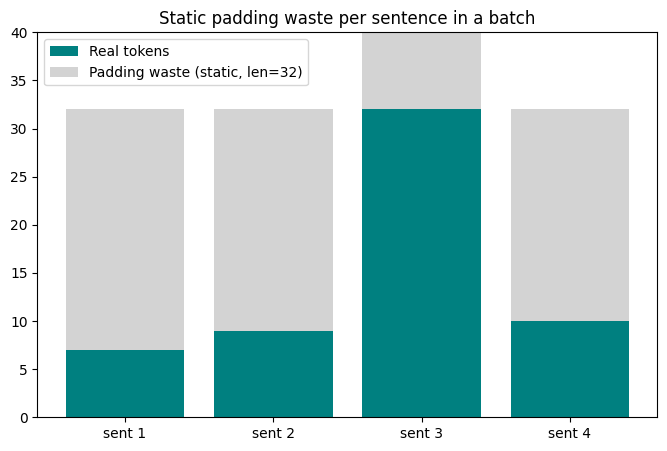

In [ ]:
import matplotlib.pyplot as plt

static_len = static_batch["input_ids"].shape[1]
fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(sample_batch))
ax.bar(x, real_lengths, label="Real tokens", color="teal")
ax.bar(x, [static_len - l for l in real_lengths], bottom=real_lengths,
       label=f"Padding waste (static, len={static_len})", color="lightgrey")
ax.set_xticks(list(x))
ax.set_xticklabels([f"sent {i+1}" for i in x])
ax.legend()
ax.set_title("Static padding waste per sentence in a batch")
plt.show()

**Discussion:** In production training loops (e.g., Hugging Face `DataCollatorWithPadding`), dynamic padding is the default because it avoids exactly this wasted compute — every wasted slot still costs a forward/backward pass.

### 15e. Attention masks

In [ ]:
print("Input IDs:     ", dynamic_batch["input_ids"][0].tolist())
print("Attention mask:", dynamic_batch["attention_mask"][0].tolist())

Input IDs:      [101, 18504, 12427, 107459, 92740, 54102, 10861, 837, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Attention mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


The attention mask tells the model which positions are real tokens (`1`) vs padding (`0`) so padding never influences the computation.

### 15f. Token type IDs — sentence-pair tasks (BERT-style only)

In [ ]:
pair_encoding = mbert_tok(urdu_corpus[0], urdu_corpus[1], return_tensors="pt")
print("Tokens:         ", mbert_tok.convert_ids_to_tokens(pair_encoding["input_ids"][0]))
print("Token type IDs: ", pair_encoding["token_type_ids"][0].tolist())

Tokens:          ['[CLS]', 'پاکستان', 'ایک', 'خوب', '##صورت', 'ملک', 'ہے', '۔', '[SEP]', 'کراچی', 'پاکستان', 'کا', 'سب', 'سے', 'بڑا', 'شہر', 'ہے', '۔', '[SEP]']
Token type IDs:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


`token_type_ids` marks which sentence each token belongs to (0 = first sentence, 1 = second) — needed for tasks like NLI or QA where the model sees two segments at once. Decoder-only models like GPT don't use this at all.

### 15g. Left-padding for decoder-style (generative) models

In [ ]:
gpt2_tok.pad_token = gpt2_tok.eos_token   # GPT-2 has no pad token by default
gpt2_tok.padding_side = "left"

gen_batch = gpt2_tok(roman_urdu_corpus[:3], padding=True, return_tensors="pt")
print("Left-padded input_ids:")
for row in gen_batch["input_ids"]:
    print(row.tolist())
print("Attention mask:")
for row in gen_batch["attention_mask"]:
    print(row.tolist())

Left-padded input_ids:
[32, 73, 285, 8717, 321, 275, 1219, 265, 257, 11693, 387, 72, 331, 283, 13]
[50256, 50256, 44, 23577, 258, 442, 1872, 275, 1219, 265, 38836, 392, 387, 72, 13]
[50256, 50256, 50256, 50256, 50256, 41428, 1388, 30693, 382, 45091, 374, 12236, 289, 2049, 13]
Attention mask:
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


**Discussion:** For generation, the model always predicts the *next* token after the last real token in the sequence. Left-padding keeps that last real token at the same position (the end) across every row in the batch, so batched generation stays aligned. Right-padding a decoder model for generation is a common, subtle bug.

### 15h. Label alignment for token classification (NER-style)

Word-level labels (e.g., named-entity tags) must be re-mapped onto subword tokens, since one word can split into several BPE/WordPiece pieces.

In [ ]:
words = urdu_corpus[0].split()
word_labels = ["B-LOC" if w == "پاکستان" else "O" for w in words]  # toy NER labels

enc = mbert_tok(words, is_split_into_words=True, return_tensors="pt")
word_ids = enc.word_ids(batch_index=0)

aligned_labels = ["SPECIAL" if wid is None else word_labels[wid] for wid in word_ids]
tokens = mbert_tok.convert_ids_to_tokens(enc["input_ids"][0])

for tok, lab in zip(tokens, aligned_labels):
    print(f"{tok:15s} -> {lab}")

[CLS]           -> SPECIAL
پاکستان         -> B-LOC
ایک             -> O
خوب             -> O
##صورت          -> O
ملک             -> O
ہے              -> O
۔               -> O
[SEP]           -> SPECIAL


**Discussion question:** If "پاکستان" splits into 2 subword pieces, should both pieces get the "B-LOC" label, or just the first (with the rest marked to be ignored in the loss)? Both conventions exist in practice — ask participants which they'd pick and why.

### 15i. Packing (pretraining-scale alternative to padding)

At LLM-pretraining scale, padding is often skipped almost entirely: documents are concatenated with a separator and sliced into fixed-size blocks, so every position in every batch is a real token.

In [ ]:
eos_id = mbert_tok.sep_token_id   # stand-in "document separator"
block_size = 20

all_ids = []
for s in urdu_corpus:
    all_ids.extend(mbert_tok(s, add_special_tokens=False)["input_ids"])
    all_ids.append(eos_id)

packed_blocks = [all_ids[i:i + block_size] for i in range(0, len(all_ids), block_size)]
print(f"{len(all_ids)} total tokens -> {len(packed_blocks)} packed blocks of size {block_size}, zero padding used")
print("First block:", packed_blocks[0])

217 total tokens -> 11 packed blocks of size 20, zero padding used
First block: [18504, 12427, 107459, 92740, 54102, 10861, 837, 102, 101190, 18504, 11503, 31552, 11689, 85015, 14304, 10861, 837, 102, 781, 36334]


**Wrap-up discussion for Task 15:**
1. Why does dynamic padding matter more as batch size grows?
2. What real production bug can happen if you fine-tune with right-padding but deploy generation with left-padding (or vice versa)?
3. For your Urdu NER use case, would you propagate labels to every subword piece, or only the first?

## Facilitator Notes

| Item | Suggestion |
|---|---|
| Group size | 3–4 per group works well for Tasks 8–12 |
| Time budget | Setup+Task1-3: 45 min · Task 4-7 (training): 45 min · Task 8-9 (pretrained/Roman Urdu): 40 min · Task 10-12 (metrics+viz): 45 min · Task 13: 20 min · Task 14 (normalization demo): 30 min · Task 15 (tokens to model input): 45 min |
| Common pitfall | Forgetting `character_coverage=1.0` in SentencePiece — silently drops Urdu characters |
| Common pitfall | Using ASCII punctuation regex on Urdu text — misses ۔ ، ؟ entirely |
| Common pitfall | Applying different normalization at training time vs inference time — this is train/serve skew, the core lesson of Task 14 |
| Common pitfall | Right-padding a decoder model at generation time instead of left-padding — breaks batched generation alignment (Task 15g) |
| Stretch goal | Have fast groups fine-tune a tiny classifier (sentiment on Urdu tweets) twice — once per tokenizer — and compare downstream accuracy, not just intrinsic metrics |